In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter

pounds = FuncFormatter(lambda value, _: f"£{value:,.0f}")

def clean_input(value):
    if isinstance(value, str):
        value = value.replace(',', '').replace('£', '').strip()
    return float(value)

class Year:

    def __init__(self, year, start_CDEL, start_RDEL, start_RAD):
        
        self.year = year
        self._starting_POT = {
            'Month': 'April',
            'CDEL' : clean_input(start_CDEL),
            'RDEL' : clean_input(start_RDEL),
            'RAD'  : clean_input(start_RAD),
            'TDEL' : clean_input(start_CDEL) + clean_input(start_RDEL) + clean_input(start_RAD)
        }

        self._previous_POT = {
            'Month': None,
            'CDEL' : None,
            'RDEL' : None,
            'RAD'  : None,
            'TDEL' : None
        }

        self._current_POT = dict(self._starting_POT)

        self.monthly_balanced_tracking = {}
        self._balanced_tracking_variance = {}
        self.monthly_pessimistic_tracking = {}
        self.monthly_optimistic_tracking = {}

    def calculate_tracking_variance(self):
        if self._current_POT['Month'] in self.monthly_balanced_tracking and self._current_POT['Month'] != 'April':
            variance = {
                'CDEL' : self._current_POT['CDEL'] - self._previous_POT['CDEL'],
                'RDEL' : self._current_POT['RDEL'] - self._previous_POT['RDEL'],
                'RAD'  : self._current_POT['RAD'] - self._previous_POT['RAD'],
                'TDEL' : self._current_POT['TDEL'] - self._previous_POT['TDEL']
            }
            self._balanced_tracking_variance[self._current_POT['Month']] = variance
            return variance

        return {
            'Month': self._current_POT['Month'],
            'CDEL' : np.nan,
            'RDEL' : np.nan,
            'RAD'  : np.nan,
            'TDEL' : np.nan
        }
    
    #  Returns a single tidy DataFrame with all scenarios — ready for matplotlib.
    def to_dataframe(self):
        rows = []
        for scenario, tracking in [
            ('Balanced',    self.monthly_balanced_tracking),
            ('Pessimistic', self.monthly_pessimistic_tracking),
            ('Optimistic',  self.monthly_optimistic_tracking),
        ]:
            for month, values in tracking.items():
                rows.append({'Month': month, 'Scenario': scenario, **values})
        return pd.DataFrame(rows)

    @property
    def starting_POT(self):
        return self._starting_POT

    @property
    def balanced_tracking(self):
        return self.monthly_balanced_tracking
    
    @property
    def balanced_tracking_variance(self):
        return self._balanced_tracking_variance

    @property
    def previous_POT(self):
        return self._previous_POT

    @property
    def current_POT(self):
        return self._current_POT

    @property
    def current_CDEL_POT(self):
        return self._current_POT['CDEL']

    @property
    def current_RDEL_POT(self):
        return self._current_POT['RDEL']

    @property
    def current_RAD_POT(self):
        return self._current_POT['RAD']

    @property
    def current_TDEL_POT(self):
        return self._current_POT['TDEL']

    @property
    def pessimistic_tracking(self):
        return self.monthly_pessimistic_tracking

    @property
    def optimistic_tracking(self):
        return self.monthly_optimistic_tracking

class Month():

    def __init__(self, year_instance, month, CDEL, RDEL, RAD):
        self.year_instance = year_instance
        self.month = month
        self.CDEL  = clean_input(CDEL)
        self.RDEL  = clean_input(RDEL)
        self.RAD   = clean_input(RAD)
        self.TDEL  = self.CDEL + self.RDEL + self.RAD

        self.year_instance.monthly_balanced_tracking[self.month] = {
            'CDEL': self.CDEL,
            'RDEL': self.RDEL,
            'RAD' : self.RAD,
            'TDEL': self.TDEL
        }

        self.year_instance._previous_POT = dict(self.year_instance._current_POT)
        
        self.year_instance._current_POT = {
            'Month': self.month,
            'CDEL' : self.CDEL,
            'RDEL' : self.RDEL,
            'RAD'  : self.RAD,
            'TDEL' : self.TDEL
        }

    def set_pessimistic_tracking(self, CDEL, RDEL, RAD):
        self.year_instance.monthly_pessimistic_tracking[self.month] = {
            'CDEL': clean_input(CDEL),
            'RDEL': clean_input(RDEL),
            'RAD' : clean_input(RAD),
            'TDEL': clean_input(CDEL) + clean_input(RDEL) + clean_input(RAD)
        }

    def set_optimistic_tracking(self, CDEL, RDEL, RAD):
        self.year_instance.monthly_optimistic_tracking[self.month] = {
            'CDEL': clean_input(CDEL),
            'RDEL': clean_input(RDEL),
            'RAD' : clean_input(RAD),
            'TDEL': clean_input(CDEL) + clean_input(RDEL) + clean_input(RAD)
        }

In [2]:
# This is the only cell the user should edit. 

FY26_27 = Year('FY26_27', '£1,000', '50', '£25'     )
April = Month(FY26_27, 'April', '£1,110', '£45', '£20')
April.set_pessimistic_tracking('£900', '£35', '£10')
April.set_optimistic_tracking('£1,200', '£55', '£30')

May = Month(FY26_27, 'May', '£1,005', '£40', '£15')
May.set_pessimistic_tracking('£850', '£30', '£5')
May.set_optimistic_tracking('£1,150', '£50', '£25')

In [3]:
# Function to format currency values in DataFrames in formt £xxx,xxx.
def format_currency(val):
    if pd.isna(val) or isinstance(val, str):
        return val
    try:
        return f"£{val:,.0f}"
    except (ValueError, TypeError):
        return val

# Helper function to display DataFrames with formatted currency and no index.
def show_df(df, title=None):
    if title:
        print(title)
    display(
        df.style
          .format(format_currency)
          .hide(axis="index")
    )


In [4]:
# Dataframes for snapshots of starting, current, previous POT and balanced tracking variance.
df_starting_POT               = pd.DataFrame([FY26_27.starting_POT])
df_current_POT                = pd.DataFrame([FY26_27.current_POT])
df_previous_POT               = pd.DataFrame([FY26_27.previous_POT])
df_balanced_tracking_variance = pd.DataFrame([FY26_27.calculate_tracking_variance()])

# Tidy DataFrame
df_all_scenarios = FY26_27.to_dataframe()

# We wont need this as we can use all scenarios df and filter in the code.
df_balanced_only = df_all_scenarios[df_all_scenarios["Scenario"] == "Balanced"]

In [5]:
#Testing
show_df(df_starting_POT, "Starting POT")
show_df(df_current_POT, "Current POT")  
show_df(df_balanced_only, "Balanced Scenario")
show_df(df_all_scenarios, "All Scenarios")
show_df(df_balanced_tracking_variance, "Balanced Tracking Variance")
print(FY26_27.balanced_tracking_variance)



Starting POT


Month,CDEL,RDEL,RAD,TDEL
April,"£1,000",£50,£25,"£1,075"


Current POT


Month,CDEL,RDEL,RAD,TDEL
May,"£1,005",£40,£15,"£1,060"


Balanced Scenario


...

All Scenarios


Month,Scenario,CDEL,RDEL,RAD,TDEL
April,Balanced,"£1,110",£45,£20,"£1,175"
May,Balanced,"£1,005",£40,£15,"£1,060"
April,Pessimistic,£900,£35,£10,£945
May,Pessimistic,£850,£30,£5,£885
April,Optimistic,"£1,200",£55,£30,"£1,285"
May,Optimistic,"£1,150",£50,£25,"£1,225"


Balanced Tracking Variance


CDEL,RDEL,RAD,TDEL
£-105,£-5,£-5,£-115


{'May': {'CDEL': -105.0, 'RDEL': -5.0, 'RAD': -5.0, 'TDEL': -115.0}}


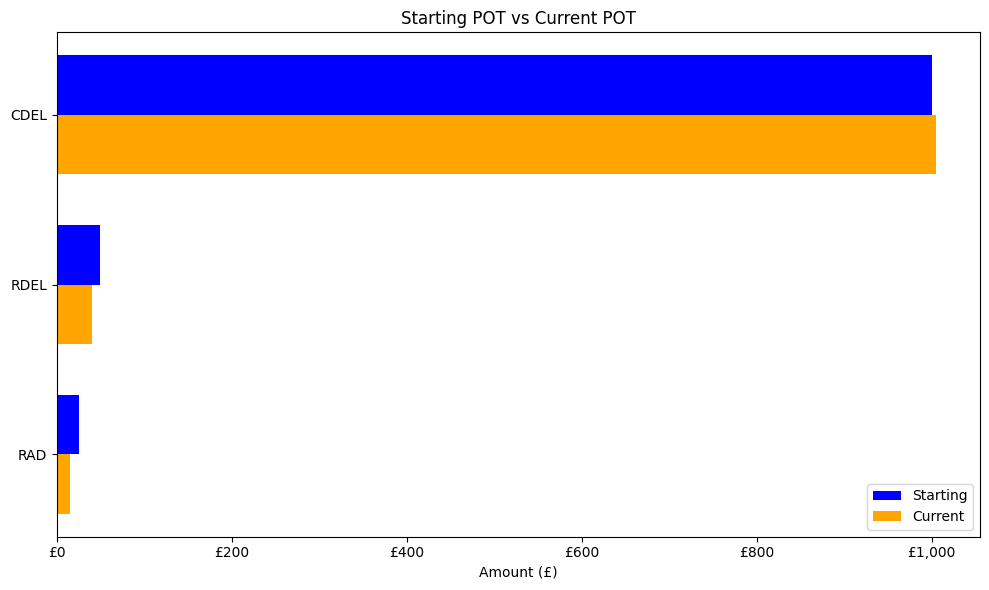

Current POT


Month,CDEL,RDEL,RAD,TDEL
May,"£1,005",£40,£15,"£1,060"


The balanced tracking variance for May is: {'May': {'CDEL': -105.0, 'RDEL': -5.0, 'RAD': -5.0, 'TDEL': -115.0}}


In [ ]:
# Graph 1 - Balanced Tracking vs Starting POT

def plot_tracking_vs_starting_pot(year_instance):
    categories = ['CDEL', 'RDEL', 'RAD']
    starting_values = [year_instance.starting_POT[item] for item in categories]
    current_values = [year_instance.current_POT[item] for item in categories]

    y = np.arange(len(categories))
    bar_height = 0.35

    plt.figure(figsize=(10, 6))
    plt.barh(y - bar_height/2, starting_values, height=bar_height, color='blue', label='Starting')
    plt.barh(y + bar_height/2, current_values, height=bar_height, color='orange', label='Current')

    plt.yticks(y, categories)
    plt.gca().invert_yaxis()
    ax = plt.gca()
    ax.xaxis.set_major_formatter(pounds)
    plt.xlabel('Amount (£)')
    plt.title('Starting POT vs Current POT')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    show_df(df_current_POT, "Current POT")
    #print(f'The balanced tracking variance for {year_instance.current_POT["Month"]} is: {year_instance.balanced_tracking_variance}')

plot_tracking_vs_starting_pot(FY26_27)

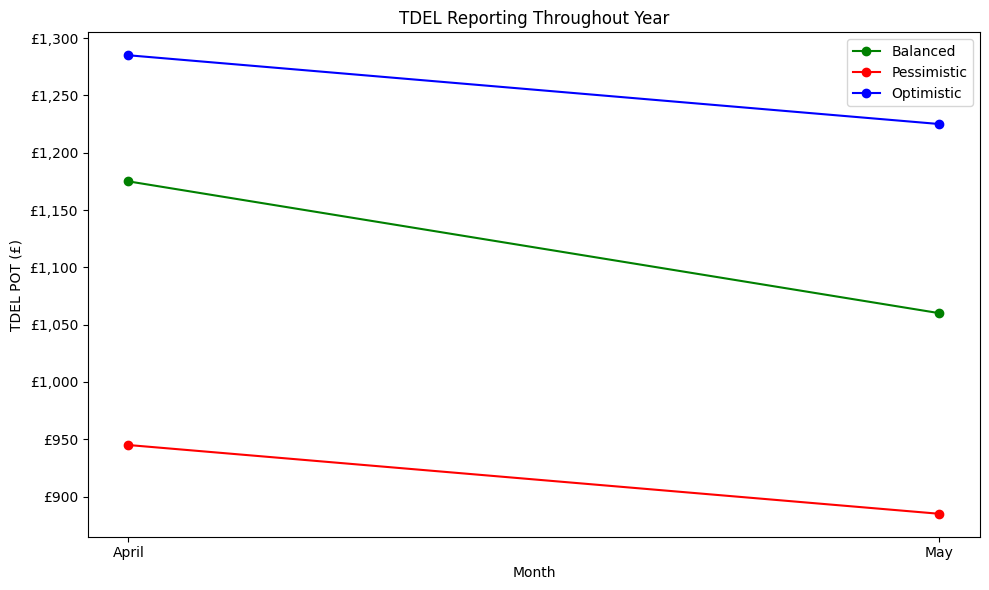

In [7]:
def plot_balanced_and_3PE(year_instance):
    categories = ['TDEL']

    plt.figure(figsize=(10, 6))
    
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['TDEL'], 
             marker='o', label='Balanced', color='green')

    # Only plot pessimistic and optimistic if they have TDEL values (i.e. if they have been set by the user).   
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['TDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['TDEL'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['TDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['TDEL'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('TDEL POT (£)')

    plt.xlabel('Month')

    plt.title('TDEL Reporting Throughout Year')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_balanced_and_3PE(FY26_27)

In [ ]:
#Need Variance Tracker for all COM

# Finally three graphs outlining the balanced, pessimistic and optimistic tracking for each seperate COM across the year.